<a href="https://colab.research.google.com/github/swapnilsha/Faster-RCNN-Object-Detection/blob/main/Faster_RCNN_Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
from torchvision import transforms as T

from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
from sklearn.metrics import *

In [2]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained = True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 118MB/s]


In [3]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [4]:
#!wget 'http://images.cocodataset.org/val2017/000000037777.jpg'
#!wget 'https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.investopedia.com%2Foffice-values-growth-slows-7486625&psig=AOvVaw0fe7O67I865BlMhAJCD3qp&ust=1725941694172000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCNjziP__tIgDFQAAAAAdAAAAABAE'
#!wget 'https://www.investopedia.com/thmb/RSJGl6EMNdiLjw0AnYIet4cboQk=/750x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/GettyImages-656544055-19ddbae5e1e1448db35b3969022eb3d0.jpg'
#!wget 'data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxMSEhUSEhMVFRUVFxUVFxcVFxcVFRUXFRUXFhUVFxUYHSggGBolHRUVITEhJSkrLi4uFx8zODMtNygtLisBCgoKDg0OGhAQGy0fHyUtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLf/AABEIAM4A9QMBIgACEQEDEQH/xAAcAAABBQEBAQAAAAAAAAAAAAAGAgMEBQcAAQj/xABHEAABAwIEAgcFBgMFBgcBAAABAAIDBBEFBhIhMUETIlFhcYGRB1KhscEjMkKS0dJigvAzcpPT4RYXQ1Oj8RUkNESDorIU/8QAGQEAAwEBAQAAAAAAAAAAAAAAAAECAwQF/8QAIxEBAQACAgICAgMBAAAAAAAAAAECESExAxJBUSIyBBNhcf/aAAwDAQACEQMRAD8AMZoVGdCrWRqYcxec60BkCkMhUiONPtjSNX1cVmO8ELxDrhGOIs+zd4IQg++F0+Dpln2LcNGym9EouGjZWgYl/I/ZWHSOIV6IlK0r0Rrn0tGEK96JSejXaE9BG6Nd0akmNcWI0EbQvNCk6FwYjQRixMFisCxRi3dXgRIjXdGpIYuLEtBEMabc1THtUd8BRJstmdkiVmy8e0gpZNwqk1RtFiZunXRr2nG6kFqefYiGY0gxKaWJJYpCC6JRp41aGNRalm6rHsVEbEuUtsey5TQs5AmS1MnFGFPxPDtwpp6pcbU8GLomp6yk0DFhaJ3ggun++Ea404dE7fkUFU39oF1eDpln2McL4K4Y1U+FHZXbHjtU+f8AZeHRQavbL1pCWAsVkAL3SnA1e2QkzpXaUp0gC4PBQfJOldoTtl5pQRlzVFI3U8tUQt3V4Eca1cWp0NXaVIRZGrxkoHFSS1V9e2wunLoEVXWKZ0bKNTPJdx2Vk8dVOZ7o0h0rd1KITVIN1KLVWfYnRgtSS1PuCQQoMwWqLUjdTyFEqW7qseyJjbsuTsY2XJADQxvDxvsjPDR1UAtzZTEg3eP5Sr+hzvRAWMpHjG/6BZ4YZ65h/wBkoxiCiYtV9G0lVtPnOhP/ALho8WvHzChY/mGlkYQydh25FV6ZfRyxXjHxMC0G9imqX+0Cp8GkjbqOpouTzCtKWdusdZvqF0eGM/JeRRBPpCYdjRvbvS6YtcNiD4bpiWAX4c1h/Lz9clePoT4XMXBWoCqMHbYK4uonSsnqRIdkq6TJwTKKSuqSCpVBISN1W4i+zlLw16HVPH+G10Fy6PglKtOR4VBlfYqcVUYg63BXjCyuptYRSgp2yq8PJPFWrUsposM/abJLVUYvJYFXRVVilPqCiriqw43O4VtKOqoFDRlqsZh1Vl4bbm0ynCLRjdTC1RqEbqaQunPtlOjJCbLU+4JBCkzBCiVXFT3NUOpG6rHsZPGDZcnIxsuSD52EP8R+H6JbYT7x+H6JTU60rrcpLIT7x9Anmwu9/wCAXNTwKD0Q2F3vD0XlRrY0uu02F+CkNKTVtuxw7ikNCv2W15mhkJsDqGw4cEUYo4tje4GxAJCA/Y3J1Zm94KL83T6KZ/eCPVcP8mb8mMbYX8dszwnN1Z0wHTuseW1vki1uZqz/AJh+CzagNpm/3vqjhpXb6z6ZS1cx5srB+O/knv8AbCr5keh/VUgSwj1it1YyZhndu5SqbOL4ramixIHHtKp2hQ8ZH2Z7t/RK4Y/S/wC3OTW27UE+tjXdoBUhVOV5NVNGf4R8la3XOpzlR4u7SC7sV4UOZul0QuPcVeHac5vEOUueYmSGMncK7ZnOLtWGUU+qoc7tKLgtMsZWWH4zhpH+2MPvBXdJVtlbqG44rGahvVPgtBypV2pGn+H6LPLBrMrtb1GLRMdpJF0ifF4yOIWMYtihmrn7mzTpH1VwHm3E+qJ49cj3tahhUwfuFMmq2tNiUK5InPQ7m9rhCebcwvFUImOtbcouO6e9TbVBVNO11z5mjms0hxeRhDi64so1Vmx5kaxp7yl6D2jUhKDzUKpkF+KBn5mdG3rFM0OYnTOuBtqsnMdC5NFj4BcqiStIA8FynSuGHAp1hTIKWwrqcqQ1OtKYaU6wpGeaUt+4PgmwvXINN9kElppm/wBcUX58b/5e/ePms99n9T0dVL/XNaFm2QPo3Hna/wBVx+fjy4tMP1rHmG0o/vI4jOyBZdn+aNaZ12jwC7GUSgU4Ey0pwOQo6CmMTbeN3gnQUiq3YfBBtP8AZ/Vh9JGL7hoROsX9nWLvaei5ArYYH3aCufKarTG7hU1Q1vEoSzxWA07vAqDnDEZGOAabAlUONTukpCSe1PGFb8M2oHWmCNmO2CBYDaUeKNoTsFtWWJyXgUW5SkvSW7LhCJRNkl14Ht7HFRl00x7ZnONNbIP4z8UVMOyGMdGmvkH8Q+QRJCeqPBVUYizI7vs3DvPzQBnFunEL9oHwJR1kd28g7/og/wBpMBbWRu5G4+Kmdqy/VKm3jHghaHq1ARXB1mN77D1VPjmGmN7JB71j5qoVeZnB6O/cEvKz+q3xCkYlEHxeShYB1dvApfA+WmSRlwbbs/RepVJUDQ2/YvFntsxQFLaU0Clgrocp9pTrSo4cnWFI0kFLBTDHJ26DVOES6KqX+uaLsWxXVTFvbYeqCwbVTu9qu3NJgd3C/os/JjLZaeN4DVR95GGHvvG3wCDqjiinCH3jatExZgpbSmWlLBQo+0rpeB8EkFKJ2QZjI77VJH9cVulEeoFimQ6Vrqp5PLYLZqaZoaBfgsc+1+PoI55oyRccjdDckLnUrxbt+SNcwVTXXCrsMpg6MttsUYizlhzwWy2PEFGtKeqPBVGecL6CoBts75hWeHOvGFsyk0lK+yPUBpkYfev8FQpzBJDHMXDu2UWKilz5CG1wePxfQqzpXdUeCYz1HqcJOxSMJpJJGAgbWT+B1RDkqUCV48E17VqdpYH82kEKVgmEujdrud1Dzox0gDSDxHhxS1dqv66UFFU9Rux2sUjGarpbMH4iPLvRdh2HNMY2SJcHaXXDQqmKVUMLPRbHkuwLDtBJNiFc1wEbeA2VW/FWhp5d45JzE6u3vaABsuQe7FiSSHC3iuS9YPYFhe3SAUq6pkeaU6xyjtKcBSCSClh6jtclhyDVc/8A6od4RtQUJLNOk7j6IKqTaphPeL+oW40hj0i1hsFOc2rCMJxGEse5p5EhXeCv+zCV7QaUMqiW8HAHz4H5BRMEf1PNUn5XrXpxrlCEqcbIg0wFOa1EbInAUGn5HdasePArTKqN2m/BZTl2YxVWvkRZaLUYxqbYBTZFY9aDmIzu6QNJKJMHqGhu6H30EssmrTYK6p8EfbcohwIe1BzXsBHEEEKpwG72hrRcojzhhjTGRtcDj3qj9m0gbOWvtsB81ekX9hHTZYldx2VrSZU0dYgko0gqo7DcfBOCsjO2yPX/AFp6xlWc8Jke3SGcOFlf5dYGRAFtrAIgxaeMbmyqX4lABsR5q5gi3VWNFM07WULMcbQzVZVVRjDQbtN/DYKuxHMetmnie7gqskL24RXY9pG24+SjPzLtezvHl6qLJEHM+7+i5lJ0jQyxF9u5T2lJlxAztt9VFjwB8lgLgX8kX4JlVkYBspFfikcV2t3IUzhet9qilyiwN3AuuUmXMLYw3UbE7rkD8WOgpYKaulgqWZ0FLBTQKUCgHrr1pTaVdBq/FdnxnvWh4bWOcY2l3EBZ3irSQ229ii7DqdxbG9gcXWHDdOXXYWftQwgCCKdvEHSfA8Pjb1QRg52IR/mds89HoIA3B3O+xCoIMmyxQumc8WtcADjz43U+0qrjd8IbR2lSaaMvNmNLj3C6HqesLnW5LWPZHSB+tx3sbfBVf8LHm6U9FleqkAtHp8f0RDQez153kf5BaW2IBKBCWsr22mOMCNJkiJnK571bMy+wDgFc3XupXMYP+K2PDtPBOupnEWU0vCiVWKRRi7nAK4Vv2qqvLrX3LgCqyLK0DHag1oParOPMccjtLbkdvL1VXmiuY1h0y2dysfoq1NM7cUwYX2H0KXTYaWm90F0GbHxAaru8t0e4ViLJmB1xuFB46qrx2O7SAEA4rg0h6zQSVrE0QKQKBp5Jap3HbAKqmrGndrz8l7DUzt+/E/8AKVv/AP4PGfwhMyYNF7oRqp9Gb4PTPlaLMIv7w+iKsMwAMs53FXzaZkY2ACGcz5j6JjtHFRvS/XXZ/NOPMpYXG/WtYDvQNQVDpIg77znHU48h3IQqq2SuqGxuf951h2N4km3gCtBkZHRUpjG5a3ieJuL796mp9t0FZmxa8thwaLLlRhplc5x7V6tJxGduyQ5OAplrDzsPH9AlgjvPwU6I8HJbf65fFR2yEkBo3PAAXcfDmT4Iiw3JlZUkaYjGObqgmP0aet8EGp9QHE+m69bNvZo3PbufRaNReytjADPMXn3WDS313PyRDheWoIT9nE0d9ru8yd0bV6X5ZlhuWKmaxEbrHm7qD04/BaVgeXZIoWMfZ2kWNtkWU1OLWspIhKi8tMcNBzEsKhfA9j7gEeB9QgmoxmmMRpmvu4jQLknu3K1SqpSWnZU02ToHddzBfjwCcgylfPFdhr6eTQ5zTsCC29iD4rR/ZXibIGv1ygXN7HlsiuqyxSk9aNp8QD81GjybSO4QtHkFdiJjZV/T5ojkfojkaXd7v0T0mMvYTd7PL9SqSlyVTxm7G6T2jY+oUiqyzA9jmvBNxub7+N0Y2RVmQmZK0s1veAOe+yqqvMkEZ0s1SO/gBcPULLcSybUtbpgrHOa5xAje48OVyD9FXOxTFKGMwmOzffa0PPqPqFcy/wARcq06vxipluerCz+Ld3oOCHanEImm5LpndruH6IFps4PJ+2+0/vcvRT6fGYX2uS0k733aPRHsntdy4zK7hYDu/VNwSAm77nv/ANV7T0zX/wBm9rwOJuAB5cVOonxjZrekcPxfgH0S2b2sijdHaNoB7SP6uolBNNGdLHG3ceqPVSJpg51t3u9xnDzV7hOVZ57GT7JnujjbvKD19JmWMWeZOjcdRPZyRsGqHheBxU4sxov281MnlDRcmwTka4zU5KvtuhzFq27g0G3YPqVR5iz9GwyMiGvowSewkcyeTQhTL+YyY5Kypdd8hIY3saOwd/FFvrN/KLlu6HOJ19m3cbABZhm3Gg5rg3hwTeL47JUONyQ3s/VCGMTknTyXPOaMsk7JsRfVMPunV4Ijz1XEdS/FVuXHilg6dw3dw8FXVtWaucd59Ark3Ub1FhhVFaME8TuvEU02GgtC8StVMWZ9LySwVCLt1xf3q2bfvY1TRih6TQ3WZZAX6RqsCLDVxsjx+k8R8Fknsup2mh1NkfFL0knXY4i+4tqYbsf5gowbjFTGLPaycD8Uf2Unmxx0k94cPBZ3ttjeF5VQj8JLfA/RRI9YOxDvEWPwVDUZ1hbtKyWLt1sdb84u0+ql4bmqgeLtqoh/fka0/EqsT3BLBVkcY3eVipTa4e4/0VdR41Tv/s5on/3XtPyKmSVgAuSEXStnZaokbN9TZMTzSaeDfVUGO5vp4ANb2N1X03Ny4t4gAeIQfV58kkeI6eIvJI+9dx3BI6reA790TH7Rc5BnNK4bkMA7SdvVTaZw4ix8FkswleNVbVEfdOjSHvbvu1zmno2jiLGxUqHG5YQ6npG9XchzpQXO7B19Ib/KtJpHvWn4hiUcQvI9re48T4BAOJ5kmncWxkhgNtMeznb23edh4cUPiF0zy5zJpHklrgNTG7j8T2nS8C1rg81NrMGkgi1S1MUQ1bMf1mbttodIzS4o1CudqlxCrq23ENO5rQSLteJHd97G903hWcGQi08L3O563G3oVcwyyOIAEc0ZsCKaUBoJuDqBFyPNPNxOEHROHh41aY4mxujPKxc0kk9xt4JpUldX0dcQ2ODopTsCDYOPYe9QarJNWzdsTj4EFX0WEM6Rk88bYNLmuZHEAJXkEEAgDgbc991tcFK1zQdNrgGx4i44Jeu6rGbfOVDhldFICaaQ77i2x7jZaVhGV6qpt0n2Mfut2K0plEzjZTGbcE/VpMFPguWYKYDS0E9p4q6CYq6tkTS+RwaB2/TtWc5tz68gx03UbwLz94+A5JW64VuYivMuboKQEE6pOTG8fPsWS5lzzPKDvp1bNaOAHaqKqqC4lziTzJO/qVTs1TSAN3JNmhDHLO1f4Ths9TE6GnYXGQ3mkOzWMB2aXHmdyvcdw0QSiFpJDWt48jzRvglZHR0zoeDo2dLIe0kbX/RZxLi7ZHue4klxJPmsssvZUx1DzGWF0NzgyTBo/E4NHmVe1mIMEZsdyqrL1v8A+hrncG3d58vmljCq5zW63R07ODGjYdvAJzBcHdEOleF7hkJnqXSuHVvt5bIqr3Ax6Rz280e3wcm+VjSSN0hcq3CtmaXcR8uS5LUVGW19K1kjmtkZIAbB7NWl3eNQBt5JdCKffpjNfkIgy3mXn6LTJsh0Y20u/O79VFkyTRjk/wAnlabZ+tQMoZko6eExyF99RIFidjwuRtdETMz4e++qSOMdr9/RsYc4nyVRVZNpI4nzOa/QwXPXcT6BRKCnwnjdng8vv/8AZEko5ixnx7DXHTE+tlefw0zC0f8AUduP5E7gtLK2UTzsbFEwuI6Z7DIQQbatLQBsVVwZobG8xUtK0NvZrmj738RDfkm63CnDTJVVwGoEhkjSJRfjpaD+irULYnxTMtEQbxRTWHVvG3oy78ILyCRvzUGXMVfVM+zi6KMEDqODIrDY2luOHYfRUlLJA02hhdPJpHWl6ziAeLYwNHqSvcQrJXE9O/QAC4NLdTi0CxHRPNm/yJjZbYIIwTNIJjwcxvVh3dcF/VJJ8Ggd6cdiMjmlrNFPEer1GiNnGzLm/wBoD3uaokcYA6RoDWNt9rI4vuw8bFoLmEd7rJ6KH8QbrsNJlmsGlnFrmueSyS3gD3oJ0MAJ6g1kX60hcGtId12aGjXYjcfeG3FSI2h421TN7erHAG31Ah33XuabDiHJMj2kgSF0zr23JbTscG9V4HAcbHS88TsrCUQss+olEjtiI4TaNptY3k+85pvwJI7kB5T1Um7GuM5AuY26uhb1bjrOeLtO22p/gpmIYyGf27w4gtBhjYSOuLDpGyBuoeDvJQ5KmaVmkBtPT2tw0gt7A3i/4BV0FZFERHSRmSS1hI4an7bdUD7o/op7Gkl9K94Dn2o4bOvG0utJqPEQuJ0/DjzXUU5uY6GIlx+9K7d57y7g1W+CZJnqT0lS4gHfSDv5u+jfVaNheDQUrQGhrQPAIktOQKZXyO8ObNUPJeCHDc2B+ZPj6LRGiw/VDWM52pafYv1O7GoMxDP9TP1YW9G3tKetNNyNRqcQji3e8Dz3VDX52ibtGLntPAeSzyOFz7vnkc6wud7DbcrPsaxd0j3lpLWE2aAeSXtCudariuKunOsv1jhxFh3WGwQtWt1u47KDgLy2mY0bXu4nmSf9LKVNKGNLjwAuufLLngdzlRY7VAERN5bnxKt/Z7hXSymV33It/Fx4D6oPkkL3Fx4uN1rOV8NNPStG+qQayPHYLS8Y6TjzltRZ6q9NO/3qiS38jPpss7CJfaDXa6nox92FoZ/Md3fRDGpTBleSnFS8KY5z7N5qLBC55s0ElEmV6a0ljxF/onSg0oKZrIgG9gPf3heNs42v/wB06/q2C96C3DnuFjW0dPDe1l4ptO3bdcmZVXMSdymmWUipj3Ucs7FrELAsjfC+OW3RvaWuubbHvWUZlwCOm60U/StvaxbY/mBsfQI+lwvWbuc4+e3oqzFcr9I2wce1LZWbZw1jrBwB7lz5ieJJ8Tf5otblGQCwcCok+VZ+QB809o1Q+ycjcEgjm0kH1CsqLME0btTJDc7EuAebdlyLryXLc4/4Z8lEkwidvGN3omF3QZk0ymV0MckhFtZ2Nhws07Kxp8ep5nB0wka6x6jGtERHuub+LzQY6mkHFjh5FKpql8bg5tw4G42+hTlIeRy1D2gsDaWJpcDpLmRuaeHUJ89rKIKuCCzYWmV/JzxcAn3Gf0UqgwurrSC67Wnm4f8A5Z+tloeXMlRQWc4Xd2nd3ryHcFXapAdhuW6utdqmLmtPb970OzfP0R/hWA0tEy7g0HmTz8Sd3L3MOYoaKO1xfkAsgxvMk9W43cWs5AKpJOyvDScd9pUUV2QjURttwQLiWa6uqNi8sb2BD8cQHepTHpXMj8UYG53Pad1b4c69lRAklX2Cxda6i1UO5srehpS0felOkeHP+u9ZnIbmyKM+VuqYMHCNtvM7n6Idw6PVKwdrgidFexrRx6WNb2AfJVuZqqzWxji7c+A/1V0gvF6npJXHkNh4BZYTeS8rqJOW6Ez1McY4Fwv4Dc/ALRsSzRGyd0TeEYIuO1o2aPNC2RbQR1FY4X6JhDe9x4D5KqwxpdIZDxcfidz/AF3q7zUziGKSgNQ9733Bc5zjx5lT48rjm5EeEsa0Pa4C5+RXNHLy9FncqqY/b3BcNiiaQAL249xVZgsOipeD3+hKtWv0kHs+SkS0YJEjeNrHwvdKVWk6qeCNuScousPkq7clTaaMsPckadIzsXKXE3a65M0KQpLUQuybUe9D+Z/7FwybUe9D+Z/7FojcUbSucbq/GT6j3ovzP/YvRlCo96L8zv2I0NwPtYnWQgq9blGf3ovzO/YnWZUn96L8zv2p6G4om0TSljDGlEUeWZh+KP1d+1Sm5dk7Wep/amNwLNwdh/7BLjwCO/3W+gRQMBk7Werv2pxuBydrPU/oiHuKylpWsHVAUPMuONpYS9x3tsO1ERweTtZ6n9FnedMhYjWSdWSmEY4B0kt/MCIq5U3JleJYlJVSmR557DkEgGyN2eyHEBt0lJ/iS/5KV/ukxD/mUn+JL/kqWYJaU9GjL/dLiH/MpP8AEl/yV472T4jykpB/8kv+SgBLpQ3cldDmIxmzBc9naiV/sdxE/wDGpf8AEl/ykQ5d9jrorPnfFI73Wufo8yWXPogM+o8nVtf0k7GtDd3XeS3UT+Fu26q8DoXMqS2Rpa6O9weR4L6KGB1LCxrTCIxtpBcLeA0boRzB7Pat9XJURGms9rAdckjTdvE2ER7vRTbarUgCxap6OJzudrDxOyCwFq+K+y7EZgBrpGgG/wDaSm//AEVEovY1WiRhfLSlocCbPlvbna8SMJqFld1TY2OgoKemH3pndK8dzfuj1LfRMUVKS9kbfwgDxcd3H5I5zF7Na6ep6Vr6bQwMaxrpJQQGjmBEQNyfgl4b7Nq1jmuc+mvcl1nyc+y8Xij4PfKkkw9zG6id03NSyWBb2brQKvJVQ4EB0P5n/sSKHJdSI9L3Q334OefmxZ6rTcZ7Ex5cGuGx4lXlGQOp3Ikdkip96H8z/wBiZGRKoODg+G/95/7EvWjcU9NRWKsn0t2+CIKfKkwtd0V+5zv2qazLkg5x+rv2pyDcCNNNpFjyXIhqcpSk3Do/V37V6jVP2j//2Q=='
#!wget'https://www.google.com/imgres?q=office&imgurl=https%3A%2F%2Fwww.architectureanddesign.com.au%2Fgetmedia%2F90cb94b6-6fc0-44f4-bba9-b1b1ca7e898e%2F6.aspx&imgrefurl=https%3A%2F%2Fwww.architectureanddesign.com.au%2Ffeatures%2Flist%2Fthe-latest-in-office-interior-design&docid=cNVAlT5UTJNDhM&tbnid=JdfLzjupPd3pbM&vet=12ahUKEwjZlJu_o7aIAxUdVmwGHYC9IccQM3oECB0QAA..i&w=600&h=450&hcb=2&ved=2ahUKEwjZlJu_o7aIAxUdVmwGHYC9IccQM3oECB0QAA'
!wget 'https://d1di04ifehjy6m.cloudfront.net/media/filer_public/67/ca/67cac7fa-1853-4f1d-95ed-db1ed6b38ec5/adobestock_212026013_2.png'

--2026-08-04 06:54:19--  https://d1di04ifehjy6m.cloudfront.net/media/filer_public/67/ca/67cac7fa-1853-4f1d-95ed-db1ed6b38ec5/adobestock_212026013_2.png
Resolving d1di04ifehjy6m.cloudfront.net (d1di04ifehjy6m.cloudfront.net)... 13.249.105.182, 13.249.105.56, 13.249.105.10, ...
Connecting to d1di04ifehjy6m.cloudfront.net (d1di04ifehjy6m.cloudfront.net)|13.249.105.182|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1510267 (1.4M) [image/png]
Saving to: ‘adobestock_212026013_2.png’

adobestock_21202601 100%[===================>]   1.44M  1.43MB/s    in 1.0s    

2026-08-04 06:54:21 (1.43 MB/s) - ‘adobestock_212026013_2.png’ saved [1510267/1510267]



In [10]:
#ig = Image.open("/content/000000037777.jpg")
#ig = Image.open("/content/hello.jpg")
#ig = Image.open("/content/imgres?q=kitchen&imgurl=https:%2F%2Fstatic.asianpaints.com%2Fcontent%2Fdam%2Fasian_paints%2Fblog%2Fbhs%2Fbhs-article5-rooted-in-modern-design-asian-paints.jpg&imgrefurl=https:%2F%2Fwww.asianpaints.com%2Fblogs%2Fhow-to-design-a-small-kit")
#ig = Image.open("/content/GettyImages-656544055-19ddbae5e1e1448db35b3969022eb3d0.jpg")
#ig = Image.open("/content/yoooooo.jpg")
ig = Image.open("/content/adobestock_212026013_2.png")

In [11]:
transform = T.ToTensor()
img = transform(ig)

In [16]:
with torch.no_grad():
  # Convert the 4-channel RGBA image to 3-channel RGB by selecting the first 3 channels.
  # This addresses the RuntimeError where the model expects 3 channels for normalization.
  img = img[:3, :, :]
  pred = model([img])

In [17]:
pred[0].keys()

dict_keys(['boxes', 'labels', 'scores'])

In [18]:
bboxes , labels , scores = pred[0]["boxes"] , pred[0]["labels"] , pred[0]["scores"]

In [ ]:
 num = torch.argwhere(scores > 0.9).shape[0]

In [ ]:
coco_names = ["person" , "bicycle" , "car" , "motorcycle" , "airplane" , "bus" , "train" , "truck" , "boat" , "traffic light" , "fire hydrant" , "street sign" , "stop sign" , "parking meter" , "bench" , "bird" , "cat" , "dog" , "horse" , "sheep" , "cow" , "elephant" , "bear" , "zebra" , "giraffe" , "hat" , "backpack" , "umbrella" , "shoe" , "eye glasses" , "handbag" , "tie" , "suitcase" ,
"frisbee" , "skis" , "snowboard" , "sports ball" , "kite" , "baseball bat" ,
"baseball glove" , "skateboard" , "surfboard" , "tennis racket" , "bottle" ,
"plate" , "wine glass" , "cup" , "fork" , "knife" , "spoon" , "bowl" ,
"banana" , "apple" , "sandwich" , "orange" , "broccoli" , "carrot" , "hot dog" ,
"pizza" , "donut" , "cake" , "chair" , "couch" , "potted plant" , "bed" ,
"mirror" , "dining table" , "window" , "desk" , "toilet" , "door" , "tv" ,
"laptop" , "mouse" , "remote" , "keyboard" , "cell phone" , "microwave" ,
"oven" , "toaster" , "sink" , "refrigerator" , "blender" , "book" ,
"clock" , "vase" , "scissors" , "teddy bear" , "hair drier" , "toothbrush" , "hair brush"]

In [20]:
font = cv2.FONT_HERSHEY_SIMPLEX

In [27]:
igg = cv2.imread("/content/adobestock_212026013_2.png")
bboxes , labels , scores = pred[0]["boxes"] , pred[0]["labels"] , pred[0]["scores"]
num = torch.argwhere(scores > 0.9).shape[0]
coco_names = ["person" , "bicycle" , "car" , "motorcycle" , "airplane" , "bus" , "train" , "truck" , "boat" , "traffic light" , "fire hydrant" , "street sign" , "stop sign" , "parking meter" , "bench" , "bird" , "cat" , "dog" , "horse" , "sheep" , "cow" , "elephant" , "bear" , "zebra" , "giraffe" , "hat" , "backpack" , "umbrella" , "shoe" , "eye glasses" , "handbag" , "tie" , "suitcase" ,
"frisbee" , "skis" , "snowboard" , "sports ball" , "kite" , "baseball bat" ,
"baseball glove" , "skateboard" , "surfboard" , "tennis racket" , "bottle" ,
"plate" , "wine glass" , "cup" , "fork" , "knife" , "spoon" , "bowl" ,
"banana" , "apple" , "sandwich" , "orange" , "broccoli" , "carrot" , "hot dog" ,
"pizza" , "donut" , "cake" , "chair" , "couch" , "potted plant" , "bed" ,
"mirror" , "dining table" , "window" , "desk" , "toilet" , "door" , "tv" ,
"laptop" , "mouse" , "remote" , "keyboard" , "cell phone" , "microwave" ,
"oven" , "toaster" , "sink" , "refrigerator" , "blender" , "book" ,
"clock" , "vase" , "scissors" , "teddy bear" , "hair drier" , "toothbrush" , "hair brush"]
for i in range(num):
  x1 , y1 , x2 , y2 = bboxes[i].numpy().astype("int")
  class_name = coco_names[labels.numpy()[i]-1]
  igg = cv2.rectangle(igg , (x1 , y1) , (x2 , y2) , (0 , 0 , 255) , 2)
  igg = cv2.putText(igg , class_name , (x1 , y1 - 10) , font , 0.5 , (255 , 0 , 0) , 1 , cv2.LINE_AA)

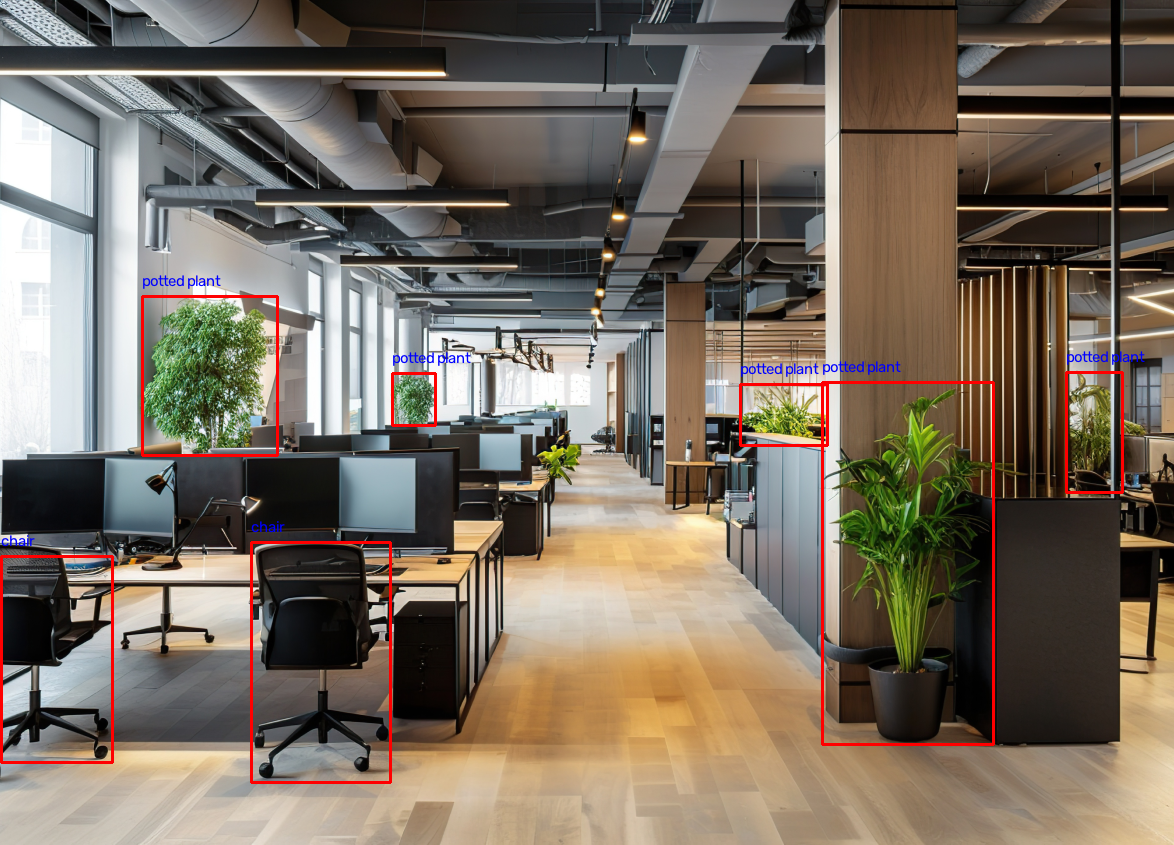

In [24]:
cv2_imshow(igg)

In [25]:
bboxes

tensor([[2.5198e+02, 5.4254e+02, 3.9032e+02, 7.8202e+02],
        [8.2260e+02, 3.8220e+02, 9.9350e+02, 7.4435e+02],
        [3.9232e+02, 3.7393e+02, 4.3555e+02, 4.2572e+02],
        [1.0664e+03, 3.7230e+02, 1.1226e+03, 4.9243e+02],
        [1.1550e+00, 5.5694e+02, 1.1245e+02, 7.6223e+02],
        [7.4071e+02, 3.8474e+02, 8.2701e+02, 4.4569e+02],
        [1.4228e+02, 2.9637e+02, 2.7738e+02, 4.5537e+02],
        [3.3561e+02, 4.5125e+02, 4.5541e+02, 5.5059e+02],
        [5.3348e+02, 4.3735e+02, 5.8163e+02, 4.8650e+02],
        [1.0736e+03, 4.6988e+02, 1.1104e+03, 4.9597e+02],
        [9.9115e+01, 4.5831e+02, 1.7559e+02, 5.4830e+02],
        [8.5513e+00, 4.5529e+02, 1.6387e+02, 5.5395e+02],
        [1.0011e+02, 4.7380e+02, 2.3147e+02, 6.5404e+02],
        [5.5511e+02, 4.3064e+02, 5.7069e+02, 4.4989e+02],
        [7.0518e+02, 4.6184e+02, 7.2725e+02, 5.1253e+02],
        [1.3749e+02, 4.4818e+02, 4.5778e+02, 5.5810e+02],
        [7.0578e+02, 4.1778e+02, 7.3950e+02, 5.1058e+02],
        [5.903

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
